In [1]:
# ==========================================
# AKILLI SULAMA TAHMİN SİSTEMİ
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Sürüm uyarılarını gizler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
# 2. VERİ YÜKLEME VE İNCELEME (AŞAMA 2)
df = pd.read_csv('irrigation_prediction.csv')

print("=== VERİ İNCELEME ===")
print("Veri Seti Boyutu:", df.shape)
print("\nHedef Değişken (Irrigation_Need) Dağılımı:")
print(df['Irrigation_Need'].value_counts())
print("\nRastgele 5 Örnek Satır:")
display(df[['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Previous_Irrigation_mm', 'Irrigation_Need']].sample(5))

print("\n=== VERİ TİPLERİ VE EKSİK VERİ KONTROLÜ ===")
df.info()
print("\nEksik Veri Var mı?", df.isnull().values.any())

=== VERİ İNCELEME ===
Veri Seti Boyutu: (10000, 20)

Hedef Değişken (Irrigation_Need) Dağılımı:
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

Rastgele 5 Örnek Satır:


,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Previous_Irrigation_mm,Irrigation_Need
8718,25.27,17.08,67.61,2360.76,10.80,71.73,Medium
3940,46.71,35.32,82.22,2125.19,9.41,108.62,Low
786,22.28,18.08,45.41,1601.72,4.47,71.28,Medium
8529,44.54,35.86,77.31,443.99,10.27,102.37,Low
6929,24.01,40.58,89.46,1418.53,5.21,33.40,Medium



=== VERİ TİPLERİ VE EKSİK VERİ KONTROLÜ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 n

In [3]:
print("\n=== SAYISAL ÖZELLİKLERİN İSTATİSTİKSEL ÖZETİ ===")
display(df.describe().T)

print("\n=== KATEGORİK ÖZELLİKLERİN SAYIMI ===")
for col in df.select_dtypes(include='object').columns:
    if col != 'Irrigation_Need':
        print(f"\n{col} Dağılımı:")
        print(df[col].value_counts())



=== SAYISAL ÖZELLİKLERİN İSTATİSTİKSEL ÖZETİ ===


,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.487857,0.979963,4.80,5.640,6.470,7.3500,8.20
Soil_Moisture,10000.0,36.969207,16.430845,8.00,22.860,37.240,50.9400,65.00
Organic_Carbon,10000.0,0.944731,0.372406,0.30,0.620,0.950,1.2600,1.60
Electrical_Conductivity,10000.0,1.791963,0.984202,0.10,0.940,1.780,2.6500,3.50
Temperature_C,10000.0,26.991423,8.664074,12.00,19.460,27.090,34.5000,42.00
Humidity,10000.0,60.080339,20.187973,25.00,42.855,60.040,77.7050,95.00
Rainfall_mm,10000.0,1252.499420,715.582201,0.38,634.155,1250.335,1880.2650,2499.69
Sunlight_Hours,10000.0,7.518538,2.016077,4.00,5.760,7.560,9.2600,11.00
Wind_Speed_kmh,10000.0,10.163545,5.670923,0.50,5.160,10.190,15.1000,20.00
Field_Area_hectare,10000.0,7.598024,4.233919,0.30,3.950,7.540,11.2025,15.00



=== KATEGORİK ÖZELLİKLERİN SAYIMI ===

Soil_Type Dağılımı:
Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64

Crop_Type Dağılımı:
Crop_Type
Rice         1711
Maize        1694
Sugarcane    1678
Potato       1663
Wheat        1659
Cotton       1595
Name: count, dtype: int64

Crop_Growth_Stage Dağılımı:
Crop_Growth_Stage
Harvest       2581
Vegetative    2521
Flowering     2465
Sowing        2433
Name: count, dtype: int64

Season Dağılımı:
Season
Rabi      3383
Kharif    3362
Zaid      3255
Name: count, dtype: int64

Irrigation_Type Dağılımı:
Irrigation_Type
Sprinkler    2527
Rainfed      2511
Drip         2495
Canal        2467
Name: count, dtype: int64

Water_Source Dağılımı:
Water_Source
River          2528
Reservoir      2513
Rainwater      2497
Groundwater    2462
Name: count, dtype: int64

Mulching_Used Dağılımı:
Mulching_Used
No     5013
Yes    4987
Name: count, dtype: int64

Region Dağılımı:
Region
South      2102
West       2017
East    

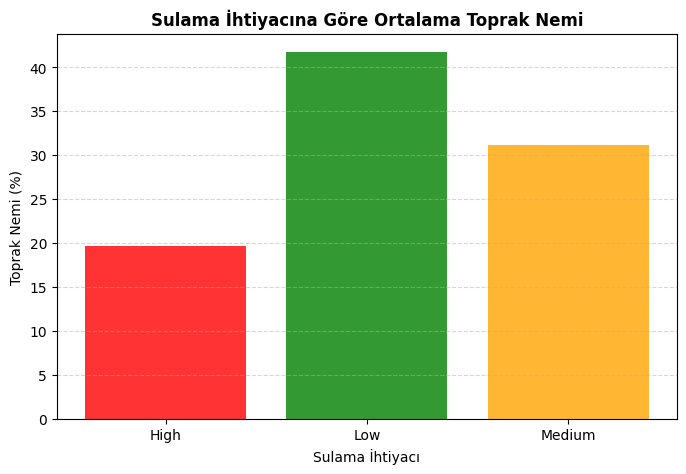

In [4]:
# Hücre 1 - Çubuk Grafik (Bar Plot)
plt.figure(figsize=(8, 5))

ortalamalar = df.groupby('Irrigation_Need')['Soil_Moisture'].mean()
renkler_bar = ['red', 'green', 'orange']

plt.bar(ortalamalar.index, ortalamalar.values, color=renkler_bar, alpha=0.8)

plt.title('Sulama İhtiyacına Göre Ortalama Toprak Nemi', fontsize=12, fontweight='bold')
plt.xlabel('Sulama İhtiyacı')
plt.ylabel('Toprak Nemi (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

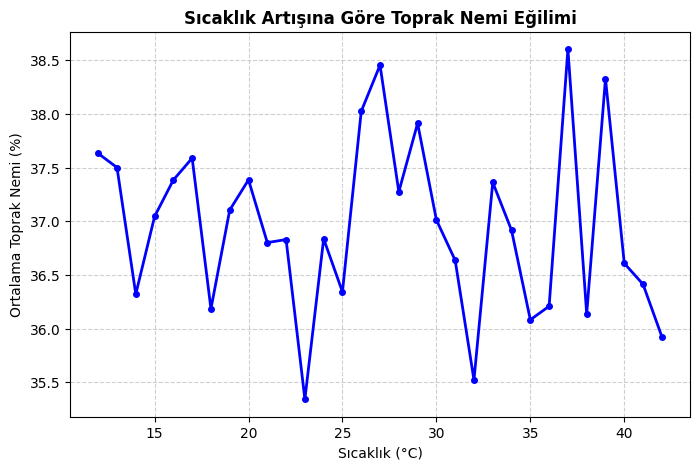

In [5]:
# Hücre 2 - Çizgi Grafiği (Line Plot)
plt.figure(figsize=(8, 5))

# Sıcaklıkları yuvarlayıp grup ortalamasını alma
df['Temp_Group'] = df['Temperature_C'].round()
cizgi_veri = df.groupby('Temp_Group')['Soil_Moisture'].mean()

plt.plot(cizgi_veri.index, cizgi_veri.values, color='blue', marker='o', linewidth=2, markersize=4)

plt.title('Sıcaklık Artışına Göre Toprak Nemi Eğilimi', fontsize=12, fontweight='bold')
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Ortalama Toprak Nemi (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [6]:
# 4. MODEL EĞİTİMİ (AŞAMA 4)
X = df[['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Previous_Irrigation_mm']]
y = df['Irrigation_Need']

# %80 Eğitim, %20 Test Bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Algoritması ile Eğitme
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

print("\n=== MODEL EĞİTİMİ ===")
print("Eğitim Verisi Sayısı:", len(X_train))
print("Test Verisi Sayısı:", len(X_test))
print("Model Başarıyla Eğitildi!")


=== MODEL EĞİTİMİ ===
Eğitim Verisi Sayısı: 8000
Test Verisi Sayısı: 2000
Model Başarıyla Eğitildi!


In [7]:
# 5. DEĞERLENDİRME VE RAPORLAMA (AŞAMA 5)
y_pred = model.predict(X_test)
basari = accuracy_score(y_test, y_pred)

print("\n=== MODEL DEĞERLENDİRME RAPORU ===")
print(f"Test Verisi Accuracy (Doğruluk) Puanı: %{basari * 100:.2f}\n")

print("Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred))

print("Karmaşıklık Matrisi (Confusion Matrix):")

siniflar = model.classes_


cm = confusion_matrix(y_test, y_pred, labels=siniflar)
cm_df = pd.DataFrame(cm, index=[f"Gerçek: {s}" for s in siniflar], columns=[f"Tahmin: {s}" for s in siniflar])

print(cm_df)


=== MODEL DEĞERLENDİRME RAPORU ===
Test Verisi Accuracy (Doğruluk) Puanı: %73.20

Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

        High       0.53      0.17      0.26        59
         Low       0.78      0.84      0.81      1204
      Medium       0.65      0.61      0.63       737

    accuracy                           0.73      2000
   macro avg       0.65      0.54      0.56      2000
weighted avg       0.72      0.73      0.72      2000

Karmaşıklık Matrisi (Confusion Matrix):
                Tahmin: High  Tahmin: Low  Tahmin: Medium
Gerçek: High              10            0              49
Gerçek: Low                0         1007             197
Gerçek: Medium             9          281             447


In [8]:
# 6. AKILLI TAHMİN ARACI / MİNİ UYGULAMA (AŞAMA 6)
def akilli_sulama_tahmin_et(toprak_nemi, sicaklik, nem, yagis, gunes_suresi, onceki_sulama):
    """
    Kullanıcıdan alınan verilerle tarlanın sulama ihtiyacını ve tavsiyesini üretir.
    """
    girdi = pd.DataFrame([[toprak_nemi, sicaklik, nem, yagis, gunes_suresi, onceki_sulama]],
                         columns=['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Previous_Irrigation_mm'])

    tahmin = model.predict(girdi)[0]

    tavsiye = {
        'Low': 'Toprak nemi ve çevre şartları uygun. Şu an sulama yapmanıza gerek yok.',
        'Medium': 'Toprak nemi sınırda. Yakın zamanda orta düzeyde sulama planlayın.',
        'High': 'Toprak oldukça kuru veya sıcaklık yüksek! Acil sulama başlatılması önerilir.'
    }

    print("\n--- CANLI TAHMİN SONUCU ---")
    print(f"Girdiler -> Nem: %{toprak_nemi}, Sıcaklık: {sicaklik}°C, Yağış: {yagis}mm, Önceki Sulama: {onceki_sulama}mm")
    print(f"Tahmini Sulama İhtiyacı: **{tahmin.upper()}**")
    print(f"Sistem Tavsiyesi: {tavsiye[tahmin]}")

# Örnek Test Senaryosu Çalıştırma
print("\n=== MİNİ UYGULAMA TESTİ ===")
# Senaryo 1: Kuru ve Sıcak Hava (Acil Sulama Beklenir -> HIGH)
print("\n[TEST 1: Kuru ve Sıcak Hava]")
akilli_sulama_tahmin_et(toprak_nemi=12.5, sicaklik=36.0, nem=28.0, yagis=10.0, gunes_suresi=9.5, onceki_sulama=5.0)

# Senaryo 2: Nemli ve Yağışlı Hava (Sulama Gerekmez -> LOW)
print("\n[TEST 2: Nemli Toprak ve Yağışlı Hava]")
akilli_sulama_tahmin_et(toprak_nemi=45.0, sicaklik=18.5, nem=82.0, yagis=1200.0, gunes_suresi=3.0, onceki_sulama=50.0)

# Senaryo 3: Ilıman Hava / Sınırda Değerler (Orta Düzey Sulama Beklenir -> MEDIUM)
print("\n[TEST 3: Ilıman Hava ve Sınırda Nem]")
akilli_sulama_tahmin_et(toprak_nemi=28.0, sicaklik=26.0, nem=50.0, yagis=300.0, gunes_suresi=6.5, onceki_sulama=20.0)

# Senaryo 4: Yüksek Sıcaklık ama Yakın Zamanda Aşırı Sulama Yapılmış Durum
print("\n[TEST 4: Sıcak Ama Önceki Sulaması Yüksek]")
akilli_sulama_tahmin_et(toprak_nemi=35.0, sicaklik=32.0, nem=40.0, yagis=50.0, gunes_suresi=8.0, onceki_sulama=80.0)



=== MİNİ UYGULAMA TESTİ ===

[TEST 1: Kuru ve Sıcak Hava]

--- CANLI TAHMİN SONUCU ---
Girdiler -> Nem: %12.5, Sıcaklık: 36.0°C, Yağış: 10.0mm, Önceki Sulama: 5.0mm
Tahmini Sulama İhtiyacı: **HIGH**
Sistem Tavsiyesi: Toprak oldukça kuru veya sıcaklık yüksek! Acil sulama başlatılması önerilir.

[TEST 2: Nemli Toprak ve Yağışlı Hava]

--- CANLI TAHMİN SONUCU ---
Girdiler -> Nem: %45.0, Sıcaklık: 18.5°C, Yağış: 1200.0mm, Önceki Sulama: 50.0mm
Tahmini Sulama İhtiyacı: **LOW**
Sistem Tavsiyesi: Toprak nemi ve çevre şartları uygun. Şu an sulama yapmanıza gerek yok.

[TEST 3: Ilıman Hava ve Sınırda Nem]

--- CANLI TAHMİN SONUCU ---
Girdiler -> Nem: %28.0, Sıcaklık: 26.0°C, Yağış: 300.0mm, Önceki Sulama: 20.0mm
Tahmini Sulama İhtiyacı: **LOW**
Sistem Tavsiyesi: Toprak nemi ve çevre şartları uygun. Şu an sulama yapmanıza gerek yok.

[TEST 4: Sıcak Ama Önceki Sulaması Yüksek]

--- CANLI TAHMİN SONUCU ---
Girdiler -> Nem: %35.0, Sıcaklık: 32.0°C, Yağış: 50.0mm, Önceki Sulama: 80.0mm
Tahmini Sula